In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("../data/nasdaq_index.csv", parse_dates=["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

df.head()

,DATE,nasdaq_close
0,2016-01-04,4903.09
1,2016-01-05,4891.43
2,2016-01-06,4835.76
3,2016-01-07,4689.43
4,2016-01-08,4643.63


In [9]:
split_date = pd.Timestamp("2025-01-01")

train = df[df["DATE"] < split_date]
test  = df[df["DATE"] >= split_date]

print(len(train), len(test))

2347 298


In [11]:
df["naive"] = df["nasdaq_close"].shift(1)

test_fc = df[df["DATE"] >= split_date].dropna()
test_fc[["DATE","nasdaq_close","naive"]].head()

,DATE,nasdaq_close,naive
2347,2025-01-01,19310.79,19310.79
2348,2025-01-02,19280.79,19310.79
2349,2025-01-03,19621.68,19280.79
2350,2025-01-06,19864.98,19621.68
2351,2025-01-07,19489.68,19864.98


In [13]:
y = test_fc["nasdaq_close"].values
yhat = test_fc["naive"].values

mae = np.mean(np.abs(y - yhat))
rmse = np.sqrt(np.mean((y - yhat)**2))
mape = np.mean(np.abs((y - yhat)/y))*100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 182.86751677852345
RMSE: 268.88047759218466
MAPE: 0.9135203414883765


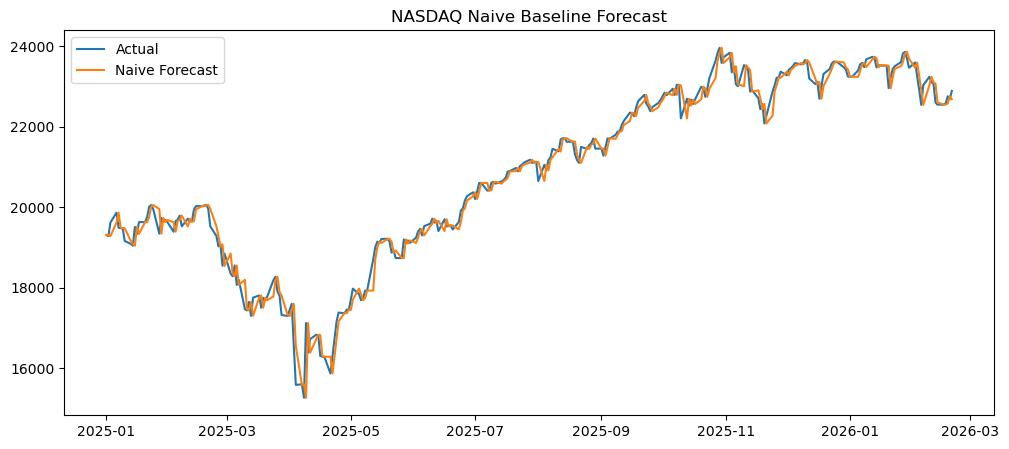

In [15]:
plt.figure(figsize=(12,5))
plt.plot(test_fc["DATE"], test_fc["nasdaq_close"], label="Actual")
plt.plot(test_fc["DATE"], test_fc["naive"], label="Naive Forecast")
plt.legend()
plt.title("NASDAQ Naive Baseline Forecast")
plt.show()